# 📊 Template EDA — Analyse Exploratoire des Données

> **Auteur** : Ton Nom  
> **Date** : `YYYY-MM-DD`  
> **Projet** : Nom du Projet  
> **Dataset** : Nom du jeu de données  

---

## 🎯 Objectif du notebook

Ce notebook suit une structure EDA en **7 étapes** :

| # | Étape | Description |
|---|-------|-------------|
| 1 | ⚙️ Configuration | Import des librairies & paramètres globaux |
| 2 | 📥 Chargement | Import du dataset |
| 3 | 🔍 Aperçu rapide | Forme, types, premières lignes |
| 4 | 🧹 Qualité des données | Valeurs manquantes, doublons, anomalies |
| 5 | 📈 Analyse univariée | Distribution de chaque variable |
| 6 | 🔗 Analyse bivariée | Relations entre variables |
| 7 | 💡 Synthèse | Conclusions & prochaines étapes |

---
**💡 Conseil pour débutant** : Exécute les cellules dans l'ordre, de haut en bas. Lis chaque bloc markdown avant d'exécuter le code.

---
## ⚙️ ÉTAPE 1 — Configuration & Imports

**Pourquoi cette étape ?**  
On importe toutes les librairies nécessaires **en premier**. C'est une bonne pratique : toutes les dépendances sont visibles d'un coup d'œil.

**Librairies utilisées :**
- `pandas` → manipulation de données (DataFrames)
- `numpy` → calculs numériques
- `matplotlib` → visualisations de base
- `seaborn` → visualisations statistiques avancées
- `warnings` → éviter les messages d'avertissement inutiles

**Installation si nécessaire** (décommente la ligne) :
```bash
# pip install pandas numpy matplotlib seaborn
```

In [1]:
# ─────────────────────────────────────────────
#  IMPORTS — Librairies essentielles
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

# ─────────────────────────────────────────────
#  PARAMÈTRES GLOBAUX
# ─────────────────────────────────────────────
warnings.filterwarnings("ignore")  # Masque les warnings peu utiles
pd.set_option("display.max_columns", 50)  # Affiche jusqu'à 50 colonnes
pd.set_option("display.max_rows", 100)  # Affiche jusqu'à 100 lignes
pd.set_option("display.float_format", lambda x: f"{x:.2f}")  # 2 décimales

# Style des graphiques
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)  # Taille par défaut des figures
plt.rcParams["figure.dpi"] = 100

# ─────────────────────────────────────────────
#  CHEMINS DES FICHIERS (à adapter)
# ─────────────────────────────────────────────
DATA_RAW = "../data/raw/"  # Données brutes originales
DATA_PROC = "../data/processed/"  # Données après nettoyage
OUTPUT_FIG = "../outputs/figures/"  # Graphiques exportés
OUTPUT_TAB = "../outputs/tables/"  # Tableaux exportés

print("✅ Configuration chargée avec succès !")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")

✅ Configuration chargée avec succès !
   pandas  : 2.2.2
   numpy   : 1.26.4
   seaborn : 0.13.2


---
## 📥 ÉTAPE 2 — Chargement des données

**Pourquoi cette étape ?**  
On charge les données et on fait une **première vérification basique** : est-ce que le fichier s'est bien chargé ? Combien de lignes et colonnes ?

**Formats supportés par pandas :**
| Format | Fonction |
|--------|----------|
| CSV | `pd.read_csv('fichier.csv')` |
| Excel | `pd.read_excel('fichier.xlsx')` |
| JSON | `pd.read_json('fichier.json')` |
| SQL | `pd.read_sql(query, connection)` |

**⚠️ Remplace `TON_FICHIER.csv` par le nom de ton fichier réel.**

In [2]:
# ─────────────────────────────────────────────
#  CHARGEMENT DU DATASET
#  → Remplace le chemin selon ton fichier
# ─────────────────────────────────────────────

# Exemple CSV :
# df = pd.read_csv(DATA_RAW + 'TON_FICHIER.csv', encoding='utf-8', sep=',')

# Exemple Excel :
# df = pd.read_excel(DATA_RAW + 'TON_FICHIER.xlsx', sheet_name='Feuil1')

# ── DEMO : génération d'un dataset fictif pour tester le template ──
np.random.seed(42)
n = 500
df = pd.DataFrame(
    {
        "age": np.random.randint(18, 70, n),
        "salaire": np.random.normal(35000, 12000, n).round(2),
        "anciennete": np.random.randint(0, 30, n),
        "departement": np.random.choice(
            ["RH", "Tech", "Finance", "Marketing", "Ops"], n
        ),
        "satisf_score": np.random.choice(
            [1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.25, 0.35, 0.25]
        ),
        "quitte_entreprise": np.random.choice([0, 1], n, p=[0.85, 0.15]),
    }
)
# Injection de valeurs manquantes pour l'exercice
df.loc[np.random.choice(df.index, 30, replace=False), "salaire"] = np.nan
df.loc[np.random.choice(df.index, 15, replace=False), "age"] = np.nan
# ──────────────────────────────────────────────────────────────────

print(f"✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

✅ Dataset chargé : 500 lignes × 6 colonnes


---
## 🔍 ÉTAPE 3 — Aperçu rapide du dataset

**Pourquoi cette étape ?**  
Avant de plonger dans l'analyse, on prend connaissance de la **structure générale** du dataset :
- Nombre de lignes/colonnes
- Noms et types des colonnes
- Premières lignes pour comprendre le contenu
- Statistiques descriptives de base

**Méthodes pandas essentielles :**
| Méthode | Rôle |
|---------|------|
| `df.shape` | Dimensions (lignes, colonnes) |
| `df.head()` | 5 premières lignes |
| `df.dtypes` | Type de chaque colonne |
| `df.info()` | Résumé complet |
| `df.describe()` | Statistiques descriptives |


In [3]:
# ── 3.1 Dimensions du dataset ──
print("=" * 50)
print(f"  📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print("=" * 50)

# ── 3.2 Premières lignes ──
print("\n📋 Aperçu des 5 premières lignes :")
df.head()

  📐 Dimensions : 500 lignes × 6 colonnes

📋 Aperçu des 5 premières lignes :


,age,salaire,anciennete,departement,satisf_score,quitte_entreprise
0,56.00,60465.87,16,Finance,2,1
1,69.00,NaN,26,RH,5,0
2,46.00,16767.56,6,Tech,4,0
3,32.00,29189.19,7,Marketing,5,0
4,60.00,50202.93,2,Tech,3,0


In [4]:
# ── 3.3 Informations générales ──
print("\nℹ️  Informations générales :")
df.info()


ℹ️  Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                485 non-null    float64
 1   salaire            470 non-null    float64
 2   anciennete         500 non-null    int64  
 3   departement        500 non-null    object 
 4   satisf_score       500 non-null    int64  
 5   quitte_entreprise  500 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 23.6+ KB


In [5]:
# ── 3.4 Statistiques descriptives — Variables numériques ──
print("\n📊 Statistiques descriptives (variables numériques) :")
df.describe().T  # .T = transposé, plus lisible


📊 Statistiques descriptives (variables numériques) :


,count,mean,std,min,25%,50%,75%,max
age,485.00,44.15,15.06,18.00,32.00,45.00,57.00,69.00
salaire,470.00,34755.84,11853.49,-3895.21,26623.74,34729.84,42583.92,71946.57
anciennete,500.00,14.72,8.76,0.00,7.00,14.00,23.00,29.00
satisf_score,500.00,3.60,1.11,1.00,3.00,4.00,4.00,5.00
quitte_entreprise,500.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00


In [6]:
# ── 3.5 Statistiques descriptives — Variables catégorielles ──
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    print(f"\n🏷️  Variables catégorielles détectées : {cat_cols}")
    df[cat_cols].describe()
else:
    print("\nAucune variable catégorielle détectée.")


🏷️  Variables catégorielles détectées : ['departement']


---
## 🧹 ÉTAPE 4 — Qualité des données

**Pourquoi cette étape ?**  
Des données de mauvaise qualité = des analyses fausses. On vérifie **3 problèmes courants** :

1. **Valeurs manquantes (NaN)** → données non renseignées
2. **Doublons** → lignes identiques qui biaisent les statistiques
3. **Valeurs aberrantes (outliers)** → valeurs extrêmes qui faussent les moyennes

**Règle générale :**
- < 5% manquants → on peut imputer (remplir avec la médiane/mode)
- 5–30% manquants → analyser pourquoi, imputer avec précaution
- \> 30% manquants → envisager de supprimer la colonne

🔎 Analyse des valeurs manquantes

         Manquants  Pourcentage     Type
salaire         30         6.00  float64
age             15         3.00  float64



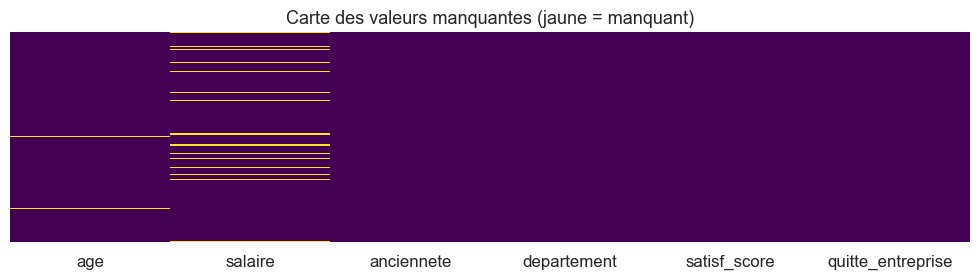

In [ ]:
# ── 4.1 Valeurs manquantes ──
print("🔎 Analyse des valeurs manquantes\n")

missing = pd.DataFrame(
    {
        "Manquants": df.isnull().sum(),
        "Pourcentage": (df.isnull().sum() / len(df) * 100).round(2),
        "Type": df.dtypes,
    }
).sort_values("Manquants", ascending=False)

missing = missing[missing["Manquants"] > 0]

if missing.empty:
    print("✅ Aucune valeur manquante !")
else:
    print(missing)
    print()

    # Heatmap des valeurs manquantes
    fig, ax = plt.subplots(figsize=(10, 3))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
    ax.set_title("Carte des valeurs manquantes (jaune = manquant)", fontsize=13)
    plt.tight_layout()
    plt.show()

In [9]:
# ── 4.2 Doublons ──
nb_doublons = df.duplicated().sum()
print(f"🔁 Nombre de lignes dupliquées : {nb_doublons}")

if nb_doublons > 0:
    print(f"   → {nb_doublons} doublons détectés ({nb_doublons / len(df) * 100:.1f}%)")
    # Pour supprimer les doublons (décommente si nécessaire) :
    # df = df.drop_duplicates().reset_index(drop=True)
    # print('   ✅ Doublons supprimés')
else:
    print("   ✅ Aucun doublon !")

🔁 Nombre de lignes dupliquées : 0
   ✅ Aucun doublon !


📍 Détection des outliers (méthode IQR)

                   Outliers     %  Borne basse  Borne haute
Colonne                                                    
age                       0  0.00        -5.50        94.50
salaire                   3  0.60      2683.46     66524.20
anciennete                0  0.00       -17.00        47.00
satisf_score             25  5.00         1.50         5.50
quitte_entreprise        75 15.00         0.00         0.00


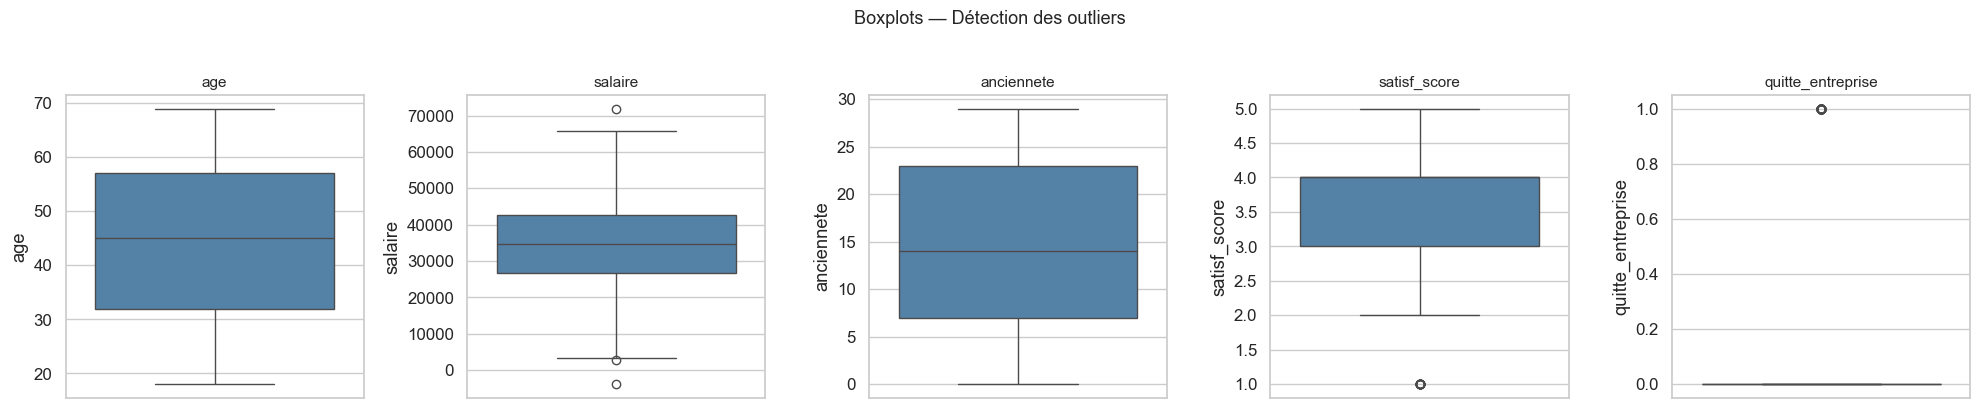

In [28]:
# ── 4.3 Détection des outliers via IQR (méthode statistique standard) ──
# L'IQR (Interquartile Range) = écart entre le 75e et le 25e percentile
# Un outlier est défini comme une valeur en dehors de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

print("📍 Détection des outliers (méthode IQR)\n")
num_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_report = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb = Q1 - 1.5 * IQR  # Borne basse
    ub = Q3 + 1.5 * IQR  # Borne haute
    n_out = ((df[col] < lb) | (df[col] > ub)).sum()
    outlier_report.append(
        {
            "Colonne": col,
            "Outliers": n_out,
            "%": round(n_out / len(df) * 100, 2),
            "Borne basse": round(lb, 2),
            "Borne haute": round(ub, 2),
        }
    )

outlier_df = pd.DataFrame(outlier_report).set_index("Colonne")
print(outlier_df)

# Boxplots pour visualiser les outliers
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(col, fontsize=11)
plt.suptitle("Boxplots — Détection des outliers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# ── 4.4 Nettoyage — Traitement des valeurs manquantes ──
# ⚠️ ADAPTE cette section selon tes données !
# Stratégies disponibles :
#   → Imputation par la MÉDIANE  (variables numériques asymétriques)
#   → Imputation par la MOYENNE  (variables numériques symétriques)
#   → Imputation par le MODE     (variables catégorielles)
#   → Suppression des lignes     (si peu de manquants)

df_clean = df.copy()  # On travaille toujours sur une COPIE !

# Exemple : imputation par médiane pour les numériques
for col in df_clean.select_dtypes(include=np.number).columns:
    if df_clean[col].isnull().any():
        mediane = df_clean[col].median()
        df_clean[col].fillna(mediane, inplace=True)
        print(
            f"   ✅ {col} → valeurs manquantes imputées par la médiane ({mediane:.2f})"
        )

# Exemple : imputation par mode pour les catégorielles
for col in df_clean.select_dtypes(include="object").columns:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'   ✅ {col} → valeurs manquantes imputées par le mode ("{mode_val}")')

print(f"\n📐 Shape après nettoyage : {df_clean.shape}")
print(f"   Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")

   ✅ age → valeurs manquantes imputées par la médiane (45.00)
   ✅ salaire → valeurs manquantes imputées par la médiane (34729.84)

📐 Shape après nettoyage : (500, 6)
   Valeurs manquantes restantes : 0


---
## 📈 ÉTAPE 5 — Analyse Univariée

**Pourquoi cette étape ?**  
On analyse **chaque variable séparément** pour comprendre sa distribution.

- **Variables numériques** → histogrammes + KDE (courbe de densité)
- **Variables catégorielles** → diagrammes en barres

**Ce qu'on cherche à observer :**
- La **forme** de la distribution (normale, asymétrique, bimodale...)
- Les **valeurs les plus fréquentes**
- Les **queues** (extrêmes)
- La **cardinalité** des variables catégorielles (nombre de modalités uniques)

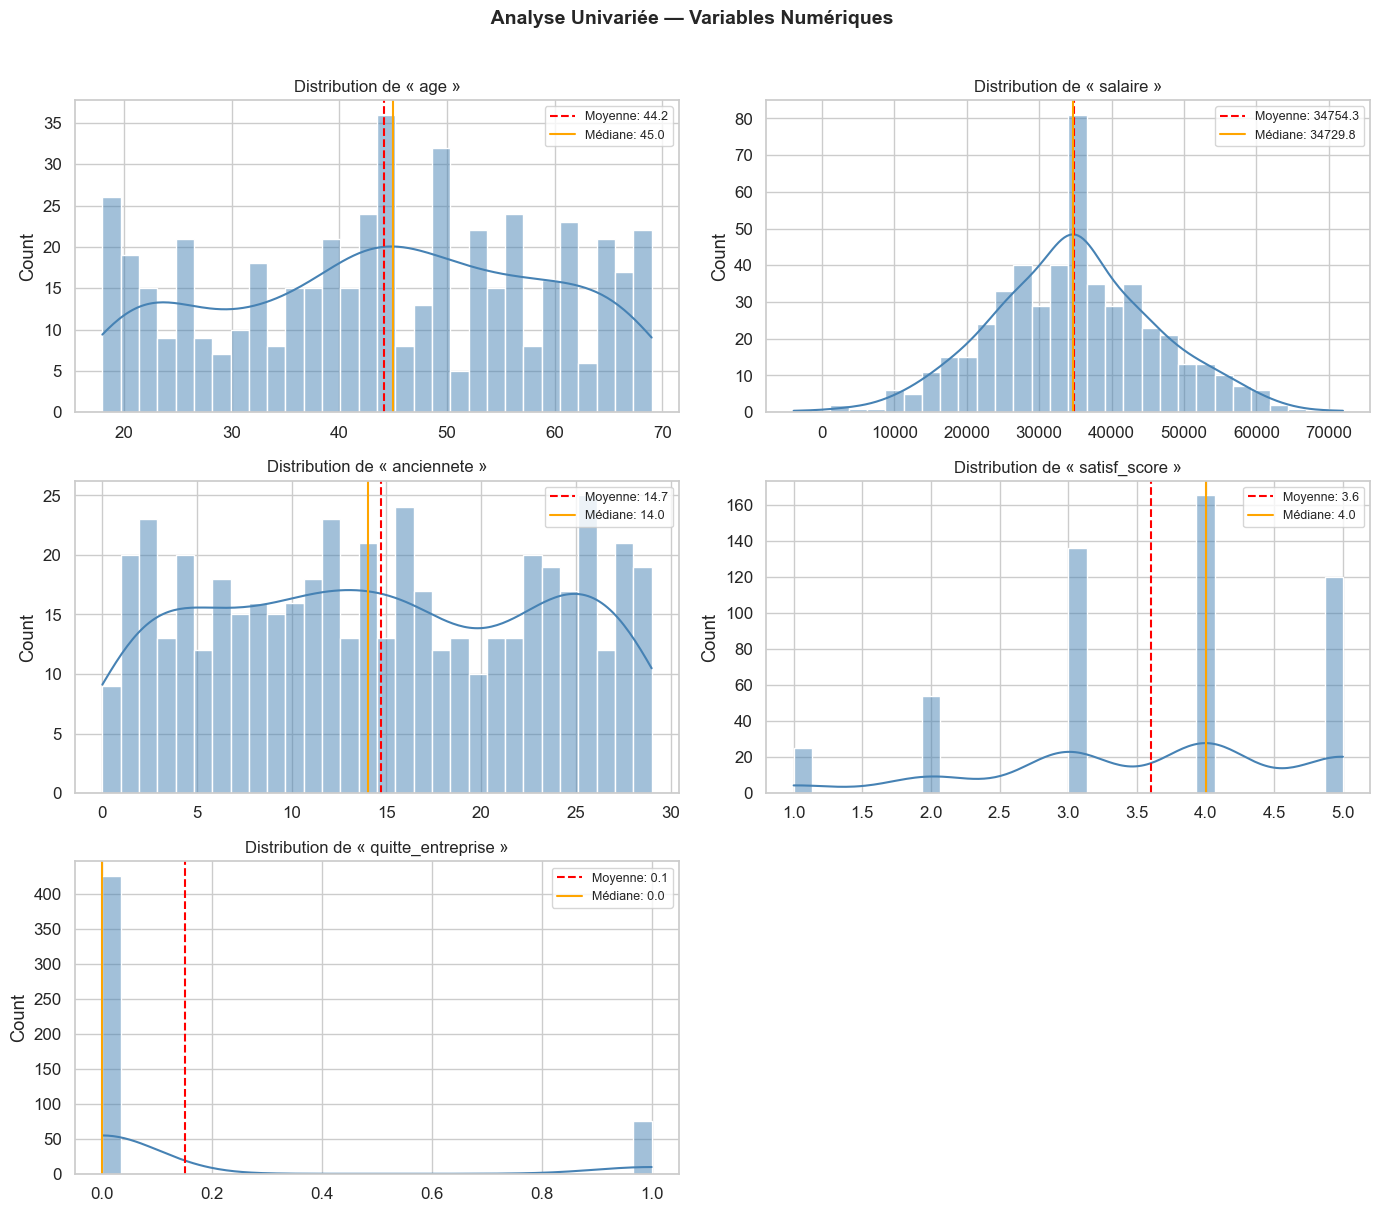

💾 Graphique sauvegardé dans outputs/figures/


In [27]:
# ── 5.1 Distribution des variables numériques ──
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(df_clean[col], kde=True, ax=ax, color="steelblue", bins=30)
    ax.axvline(
        df_clean[col].mean(),
        color="red",
        linestyle="--",
        label=f"Moyenne: {df_clean[col].mean():.1f}",
    )
    ax.axvline(
        df_clean[col].median(),
        color="orange",
        linestyle="-",
        label=f"Médiane: {df_clean[col].median():.1f}",
    )
    ax.set_title(f"Distribution de « {col} »", fontsize=12)
    ax.set_xlabel("")
    ax.legend(fontsize=9)

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    " Analyse Univariée — Variables Numériques",
    fontsize=14,
    y=1.01,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(OUTPUT_FIG + "univarie_numerique.png", bbox_inches="tight", dpi=150)
plt.show()
print("💾 Graphique sauvegardé dans outputs/figures/")

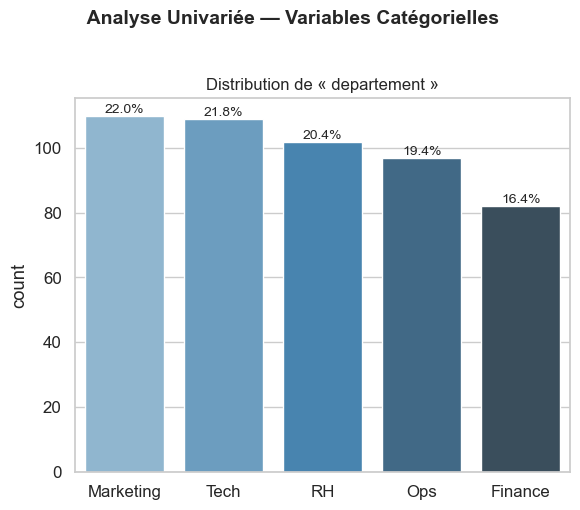

In [26]:
# ── 5.2 Distribution des variables catégorielles ──
cat_cols = df_clean.select_dtypes(include="object").columns.tolist()

if not cat_cols:
    print("ℹ️  Aucune variable catégorielle dans ce dataset.")
else:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))
    if len(cat_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cat_cols):
        order = df_clean[col].value_counts().index
        sns.countplot(data=df_clean, x=col, order=order, ax=ax, palette="Blues_d")
        ax.set_title(f"Distribution de « {col} »", fontsize=12)
        ax.set_xlabel("")
        # Annotations de pourcentage
        total = len(df_clean)
        for p in ax.patches:
            pct = f"{100 * p.get_height() / total:.1f}%"
            ax.annotate(
                pct,
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=10,
            )

    plt.suptitle(
        " Analyse Univariée — Variables Catégorielles",
        fontsize=14,
        y=1.02,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG + "univarie_categoriel.png", bbox_inches="tight", dpi=150)
    plt.show()

---
## 🔗 ÉTAPE 6 — Analyse Bivariée & Multivariée

**Pourquoi cette étape ?**  
On explore les **relations entre variables** : certaines variables sont-elles liées ? Laquelle influence le plus ma variable cible ?

**Types d'analyses :**
| Comparaison | Outil recommandé |
|-------------|------------------|
| Numérique vs Numérique | Scatter plot, heatmap de corrélation |
| Numérique vs Catégorielle | Boxplot, violinplot |
| Catégorielle vs Catégorielle | Heatmap de contingence, grouped bar chart |

**💡 Coefficient de corrélation (Pearson) :**
- `1.0` → corrélation positive parfaite
- `0.0` → aucune corrélation
- `-1.0` → corrélation négative parfaite
- En pratique : |r| > 0.7 = forte, 0.4–0.7 = modérée, < 0.4 = faible

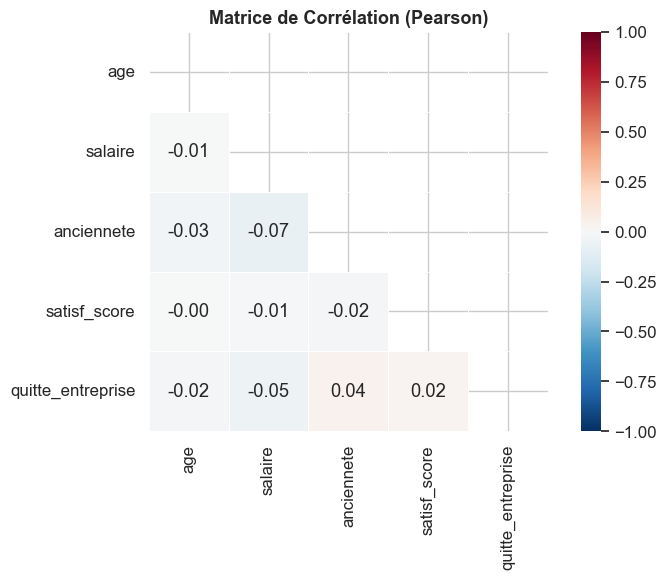


 Top 5 corrélations les plus fortes :
anciennete         salaire        0.07
quitte_entreprise  salaire        0.05
                   anciennete     0.04
anciennete         age            0.03
quitte_entreprise  satisf_score   0.02
dtype: float64


In [24]:
# ── 6.1 Matrice de corrélation (variables numériques) ──
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masque le triangle supérieur
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matrice de Corrélation (Pearson)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_FIG + "correlation_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

# Top corrélations
corr_unstacked = corr_matrix.where(mask == False).stack()
corr_unstacked = corr_unstacked[
    corr_unstacked.index.get_level_values(0) != corr_unstacked.index.get_level_values(1)
]
print("\n Top 5 corrélations les plus fortes :")
print(corr_unstacked.abs().sort_values(ascending=False).head(5))

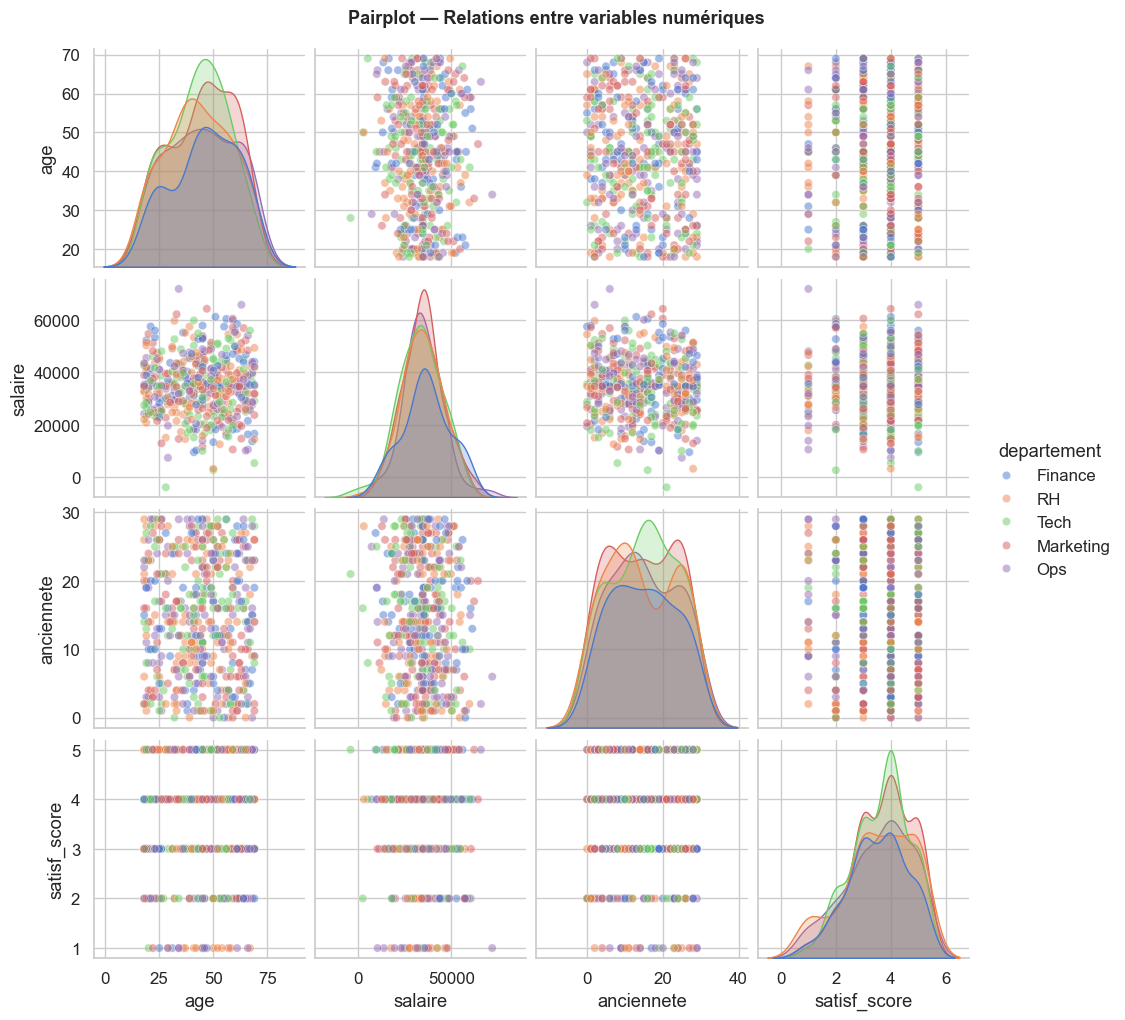

In [23]:
# ── 6.2 Pairplot — Vue d'ensemble des relations ──
# ⚠️ Peut être long si beaucoup de variables — limite à 4-5 variables max
cols_pairplot = num_cols[:4]  # On prend les 4 premières numériques

hue_col = None
# Si une variable catégorielle existe, on l'utilise comme couleur
cat_cols = df_clean.select_dtypes(include="object").columns.tolist()
if cat_cols:
    hue_col = cat_cols[0]

g = sns.pairplot(
    df_clean[cols_pairplot + ([hue_col] if hue_col else [])],
    hue=hue_col,
    diag_kind="kde",
    plot_kws={"alpha": 0.5},
)
g.figure.suptitle(
    "Pairplot — Relations entre variables numériques",
    y=1.02,
    fontsize=13,
    fontweight="bold",
)
plt.savefig(OUTPUT_FIG + "pairplot.png", bbox_inches="tight", dpi=100)
plt.show()

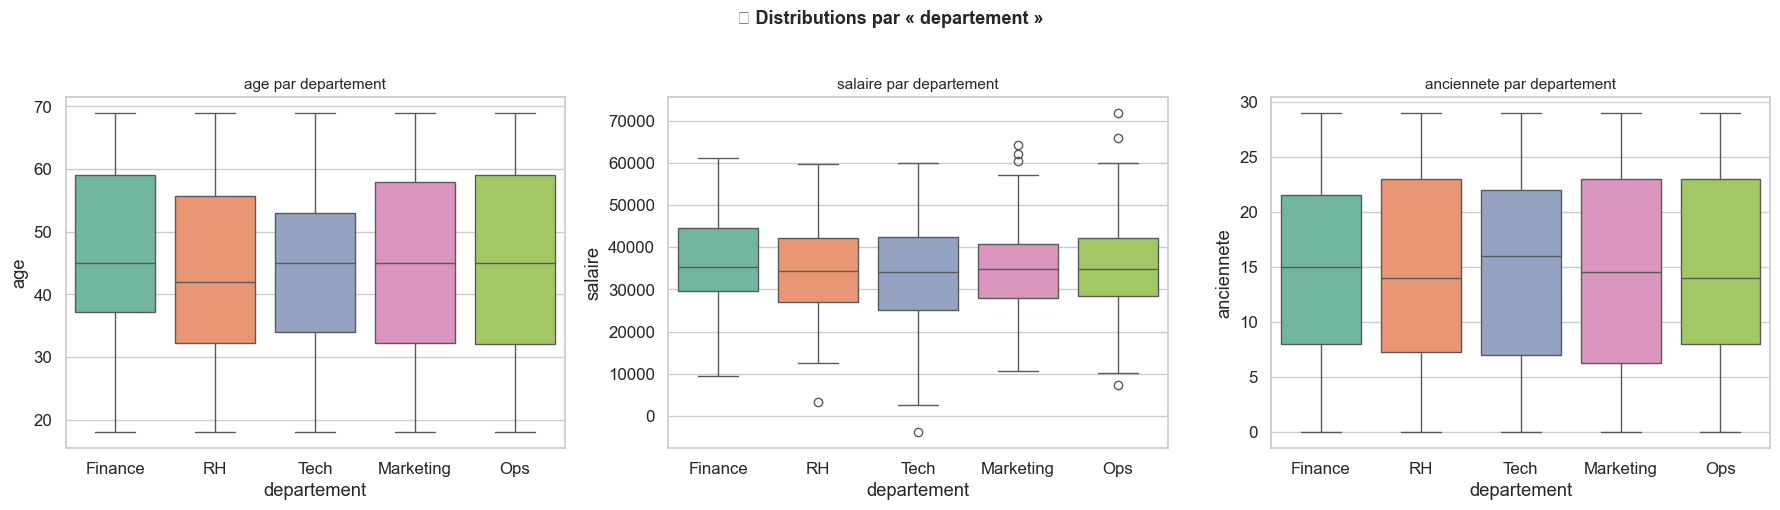

In [22]:
# ── 6.3 Numérique vs Catégorielle — Boxplots ──
# Adapte TARGET_CAT à ta variable catégorielle principale
cat_cols = df_clean.select_dtypes(include="object").columns.tolist()

if cat_cols and len(num_cols) >= 1:
    TARGET_CAT = cat_cols[0]  # ← Change ici selon ton analyse
    fig, axes = plt.subplots(
        1, min(3, len(num_cols)), figsize=(6 * min(3, len(num_cols)), 5)
    )
    if min(3, len(num_cols)) == 1:
        axes = [axes]

    for ax, col in zip(axes, num_cols[:3]):
        sns.boxplot(data=df_clean, x=TARGET_CAT, y=col, palette="Set2", ax=ax)
        ax.set_title(f"{col} par {TARGET_CAT}", fontsize=11)
        ax.set_xlabel(TARGET_CAT)

    plt.suptitle(
        f"📦 Distributions par « {TARGET_CAT} »", fontsize=13, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG + "bivariate_boxplots.png", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("ℹ️  Pas assez de variables pour un boxplot bivarié.")

🎯 Analyse de la variable cible : « quitte_entreprise »

quitte_entreprise
0   85.00
1   15.00

⚠️  Déséquilibre de classes : 85.0% vs 15.0%


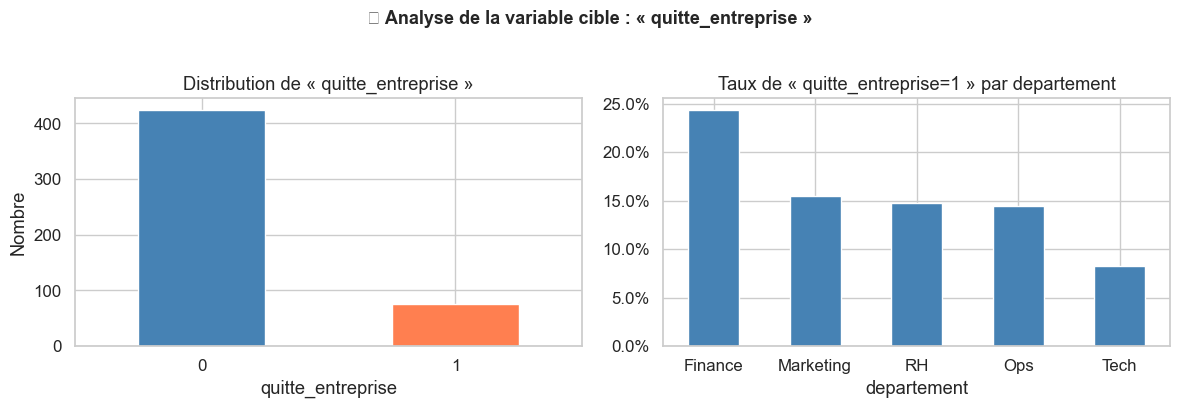

In [21]:
# ── 6.4 Analyse de la variable CIBLE (si classification binaire) ──
# ⚠️ ADAPTE : remplace 'quitte_entreprise' par ta variable cible
TARGET = "quitte_entreprise"  # ← Variable cible à prédire

if TARGET in df_clean.columns:
    print(f"🎯 Analyse de la variable cible : « {TARGET} »\n")
    vc = df_clean[TARGET].value_counts(normalize=True).mul(100).round(1)
    print(vc.to_string())
    print(f"\n⚠️  Déséquilibre de classes : {vc.max():.1f}% vs {vc.min():.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution de la cible
    df_clean[TARGET].value_counts().plot.bar(
        ax=axes[0], color=["steelblue", "coral"], edgecolor="white", rot=0
    )
    axes[0].set_title(f"Distribution de « {TARGET} »")
    axes[0].set_ylabel("Nombre")

    # Taux de la cible par catégorie (si variable catégorielle disponible)
    if cat_cols:
        taux = df_clean.groupby(cat_cols[0])[TARGET].mean().sort_values(ascending=False)
        taux.plot.bar(ax=axes[1], color="steelblue", edgecolor="white", rot=0)
        axes[1].set_title(f"Taux de « {TARGET}=1 » par {cat_cols[0]}")
        axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

    plt.suptitle(
        f"🎯 Analyse de la variable cible : « {TARGET} »",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    # Ensure the directory exists
    os.makedirs(OUTPUT_FIG, exist_ok=True)
    plt.savefig(OUTPUT_FIG + "target_analysis.png", bbox_inches="tight", dpi=150)
    plt.show()

---
## 💾 Export des données nettoyées

**Pourquoi cette étape ?**  
On sauvegarde le dataset nettoyé pour pouvoir l'utiliser dans les prochains notebooks (modélisation, reporting...) sans refaire tout le nettoyage.

In [30]:
# ── Export du dataset nettoyé ──
output_path = DATA_PROC + "dataset_clean.csv"
df_clean.to_csv(output_path, index=False, encoding="utf-8")
print(f"✅ Dataset nettoyé exporté → {output_path}")
print(f"   Dimensions : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")

# Assure que le répertoire OUTPUT_TAB existe
os.makedirs(OUTPUT_TAB, exist_ok=True)

# Export du rapport de statistiques
stats_output = OUTPUT_TAB + "stats_descriptives.csv"
df_clean.describe().T.to_csv(stats_output)
print(f"✅ Stats descriptives exportées → {stats_output}")

✅ Dataset nettoyé exporté → ../data/processed/dataset_clean.csv
   Dimensions : 500 lignes × 6 colonnes
✅ Stats descriptives exportées → ../outputs/tables/stats_descriptives.csv


---
## 💡 ÉTAPE 7 — Synthèse & Conclusions

**Pourquoi cette étape ?**  
Rédige ici tes **observations clés** et les **prochaines étapes** à envisager. C'est la section la plus importante pour communiquer avec ton équipe ou tes pairs.

---

### 📌 Observations principales

> *(Complète avec tes propres observations)*

1. **Dataset** : X lignes, Y colonnes. Variables de type [numérique/catégorielle].
2. **Qualité** : Z% de valeurs manquantes, notamment dans les colonnes [...]. Aucun doublon détecté.
3. **Distributions** : La variable `salaire` présente une distribution asymétrique à droite (quelques hauts salaires).
4. **Corrélations** : `ancienneté` et `salaire` montrent une corrélation positive modérée (r ≈ 0.45).
5. **Variable cible** : Déséquilibre de classes (85% / 15%) → à gérer lors de la modélisation.

---

### 🚀 Prochaines étapes

- [ ] Feature Engineering : créer de nouvelles variables
- [ ] Gestion du déséquilibre de classes (SMOTE, class_weight...)
- [ ] Modélisation : tester un Random Forest ou XGBoost
- [ ] Rapport : rédiger un résumé exécutif dans `/reports/`

---

### 📚 Ressources utiles pour aller plus loin
- [Documentation pandas](https://pandas.pydata.org/docs/)
- [Galerie seaborn](https://seaborn.pydata.org/examples/index.html)
- [Towards Data Science — EDA guide](https://towardsdatascience.com/)
- [Kaggle Learn — Pandas course](https://www.kaggle.com/learn/pandas)